# 🧪 Ingeniería de Características (Feature Engineering)
Este notebook implementa la creación de variables avanzadas para el modelo predictivo de la UFC, siguiendo el patrón **ELT**. Las transformaciones complejas y los cálculos históricos agrupados se ejecutan directamente en el motor analítico de **DuckDB** mediante consultas SQL.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mma_project.data.loader import get_engine

# Inicializamos el motor analítico conectado a DuckDB
engine = get_engine()
print("🥊 Conexión establecida con éxito desde el entorno de Jupyter.")

🥊 Conexión establecida con éxito desde el entorno de Jupyter.


In [5]:
query = """
WITH striking_perf AS (
    SELECT 
        fight_id,
        fighter_1,
        fighter_2,
        weight_class,
        (str_1 - str_2) AS striking_diff_f1,
        (str_2 - str_1) AS striking_diff_f2,
        CASE WHEN result_1 = 'W' THEN 1 ELSE 0 END as win_f1,
        round_num,
        fight_time
    FROM fights
),
f1_streaks AS (
    SELECT 
        fight_id,
        fighter_1,
        striking_diff_f1,
        -- Calcula la suma acumulada de victorias anteriores para el peleador 1
        SUM(win_f1) OVER (
            PARTITION BY fighter_1 
            ORDER BY fight_id
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        ) as cumulative_wins_f1
    FROM striking_perf
)
SELECT 
    p.fight_id,
    p.fighter_1,
    p.fighter_2,
    p.weight_class,
    p.striking_diff_f1,
    COALESCE(s.cumulative_wins_f1, 0) as win_streak_f1
FROM striking_perf p
JOIN f1_streaks s ON p.fight_id = s.fight_id AND p.fighter_1 = s.fighter_1;
"""

# Ejecutamos la transformación en DuckDB y traemos el resultado optimizado a Pandas
with engine.connect() as conn:
    df_features = pd.read_sql(query, conn)

# Mostramos el DataFrame resultante con las nuevas variables analíticas
df_features.head()

,fight_id,fighter_1,fighter_2,weight_class,striking_diff_f1,win_streak_f1
0,4a0db214d9721d6e,Merab Dvalishvili,Petr Yan,Bantamweight,-5.0,2
1,dfa692db6d39330c,Alexandre Pantoja,Joshua Van,Flyweight,4.0,10
2,fbbb9e72900b71f5,Brandon Moreno,Tatsuro Taira,Flyweight,-19.0,6
3,1dc29f4c6fcdd356,Henry Cejudo,Payton Talbott,Bantamweight,-74.0,0
4,6d6ab10cbaa45e8c,Jan Blachowicz,Bogdan Guskov,Light Heavyweight,4.0,3


## 📊 Distribución Estadística de las Variables Creadas
Analizaremos el comportamiento probabilístico de nuestras nuevas variables para verificar si tienen poder predictivo o si presentan asimetrías severas.

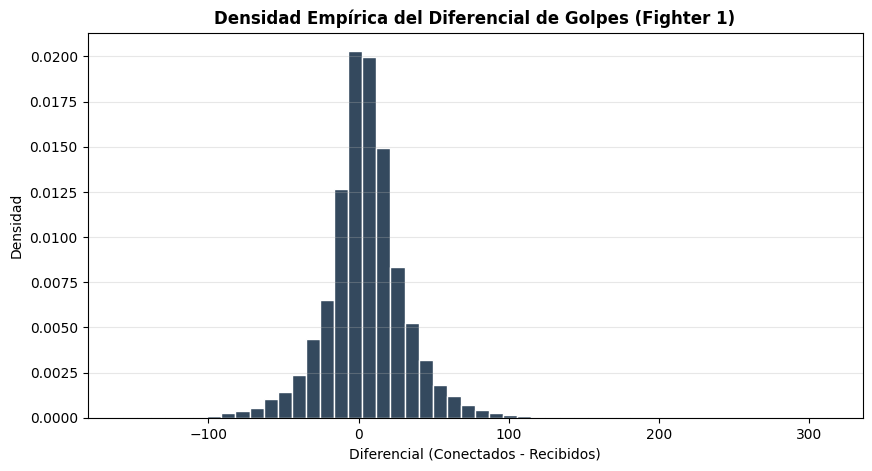

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df_features['striking_diff_f1'], bins=50, color='#34495e', edgecolor='white', density=True)
plt.title('Densidad Empírica del Diferencial de Golpes (Fighter 1)', fontsize=12, fontweight='bold')
plt.xlabel('Diferencial (Conectados - Recibidos)')
plt.ylabel('Densidad')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Figure size 1000x600 with 0 Axes>

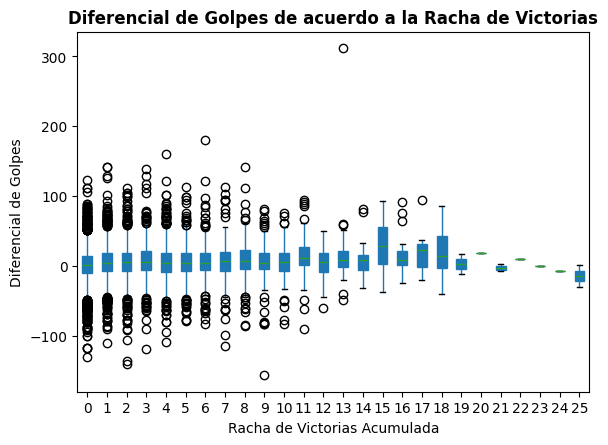

In [7]:
plt.figure(figsize=(10, 6))
# Agrupamos por racha para ver si los peleadores con más victorias dominan más el striking
df_features.boxplot(column='striking_diff_f1', by='win_streak_f1', grid=False, patch_artist=True)
plt.title('Diferencial de Golpes de acuerdo a la Racha de Victorias', fontsize=12, fontweight='bold')
plt.suptitle('') # Elimina el título automático secundario de Pandas
plt.xlabel('Racha de Victorias Acumulada')
plt.ylabel('Diferencial de Golpes')
plt.show()